In [ ]:
# CT Image Processing and Analysis
'''Objective
To read CT scans in DICOM and NIFTI formats, 
visualize them in different planes, perform format conversion, 
and apply preprocessing techniques such as windowing and normalization.'''

In [1]:
#Import the required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import nibabel as nib

In [15]:
#setting path for dataset 
nifti_path = r"S:\Research IITJ\CT_PROJECT\Nifti\Task07_Pancreas\Task07_Pancreas\imagesTr\pancreas_001.nii.gz"
dicom_path = r"S:\Research IITJ\CT_PROJECT\DICOM\manifest-1555593711945\Anti-PD-1_Lung\PD-1-Lung-00002\02-09-2010-NA-CT CHEST PULMONARY EMBOLISM W CONTRAST-71856\5.000000-PE CHEST  1.5  I31f  2  F0.6-09391"


In [16]:
reader = sitk.ImageSeriesReader()

dicom_names = reader.GetGDCMSeriesFileNames(dicom_path)

print("Number of DICOM files:", len(dicom_names))

reader.SetFileNames(dicom_names)

image = reader.Execute()

ct_array = sitk.GetArrayFromImage(image)

print("DICOM Shape:", ct_array.shape)

Number of DICOM files: 234
DICOM Shape: (234, 512, 512)


In [14]:
## Loading and Visualizing NIFTI Data
nifti = nib.load(nifti_path)
nifti_data = nifti.get_fdata()

print("NIFTI Shape:", nifti_data.shape)

NIFTI Shape: (512, 512, 110)


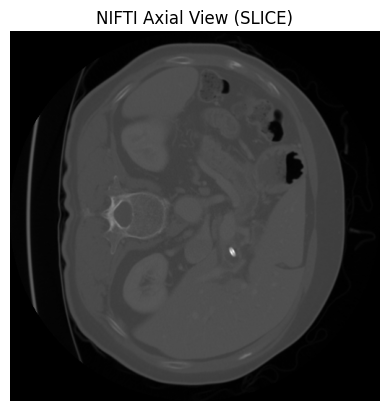

In [20]:
# show a middle slice from NIFTI
plt.imshow(nifti_data[:, :, nifti_data.shape[2]//2], cmap='gray')
plt.title("NIFTI Axial View (SLICE)")
plt.axis('off')
plt.show()

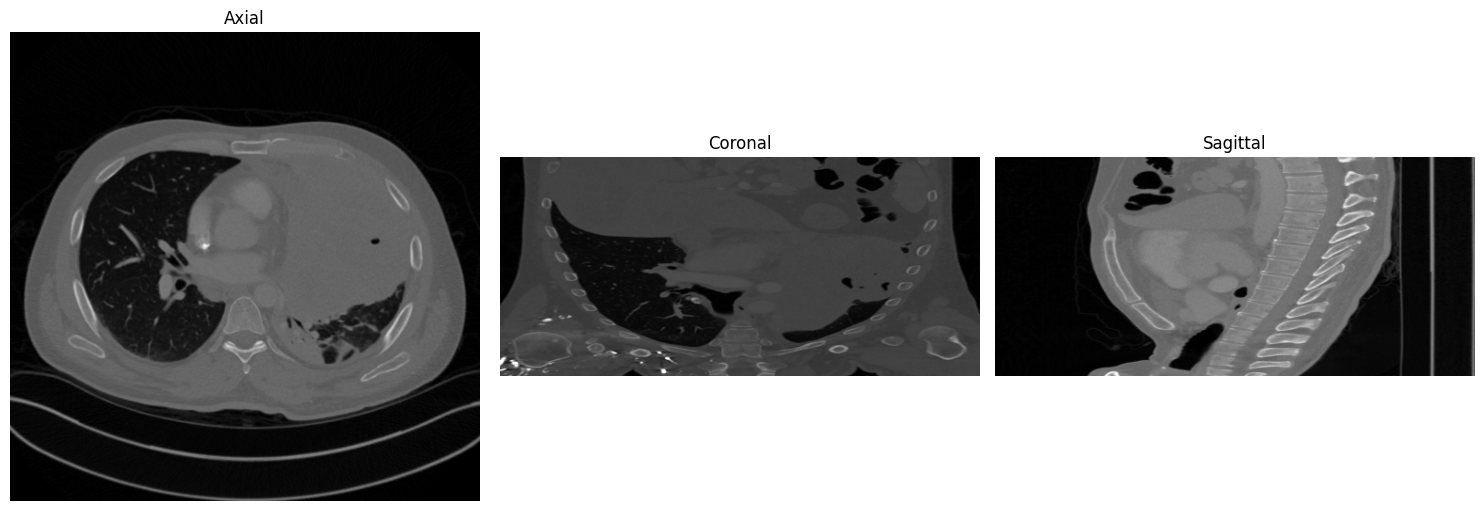

In [21]:
# visualizing all 3 planes

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# middle indices
z = ct_array.shape[0] // 2
y = ct_array.shape[1] // 2
x = ct_array.shape[2] // 2

# Axial
axes[0].imshow(ct_array[z], cmap='gray')
axes[0].set_title("Axial")

# Coronal
axes[1].imshow(ct_array[:, y, :], cmap='gray')
axes[1].set_title("Coronal")

# Sagittal
axes[2].imshow(ct_array[:, :, x], cmap='gray')
axes[2].set_title("Sagittal")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
# saving the DICOM volume as NIFTI
sitk.WriteImage(image, "ct_from_dicom.nii")

print("DICOM converted to NIFTI and saved")

DICOM converted to NIFTI and saved


In [32]:
# reconstructing image from numpy array

reconstructed = sitk.GetImageFromArray(ct_array)

# copying metadata so orientation stays correct
reconstructed.SetSpacing(image.GetSpacing())
reconstructed.SetOrigin(image.GetOrigin())
reconstructed.SetDirection(image.GetDirection())

# saving reconstructed image
sitk.WriteImage(reconstructed, "reconstructed_ct.nii")

print("Reconstructed volume saved")

Reconstructed volume saved


In [33]:
original = sitk.GetArrayFromImage(image)
reconstructed_arr = sitk.GetArrayFromImage(reconstructed)

# checking difference
difference = np.mean(np.abs(original - reconstructed_arr))

print("Mean difference:", difference)

Mean difference: 0.0


In [35]:
# function for windowing
def window_image(img, level, width):
    lower = level - width // 2
    upper = level + width // 2
    return np.clip(img, lower, upper)

# applying on middle slice
slice_img = ct_array[ct_array.shape[0]//2]

windowed = window_image(slice_img, 50, 450)

In [36]:
# normalizing between 0 and 1
normalized = (windowed - np.min(windowed)) / (np.max(windowed) - np.min(windowed))

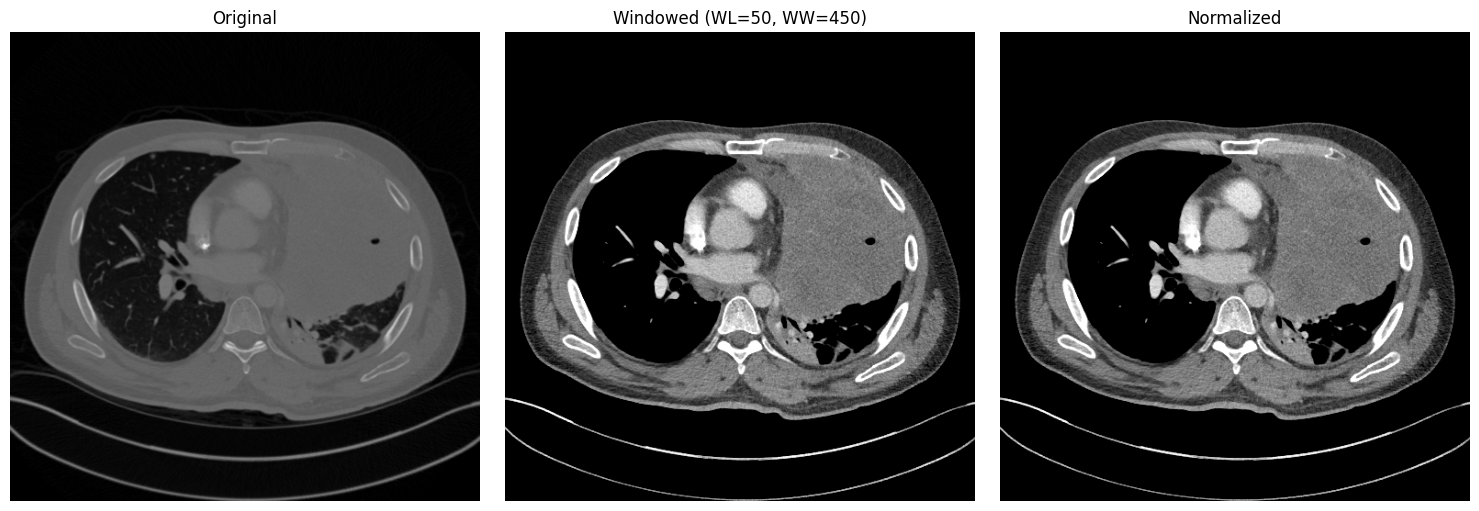

In [37]:
fig, ax = plt.subplots(1, 3, figsize=(15,5))

ax[0].imshow(slice_img, cmap='gray')
ax[0].set_title("Original")

ax[1].imshow(windowed, cmap='gray')
ax[1].set_title("Windowed (WL=50, WW=450)")

ax[2].imshow(normalized, cmap='gray')
ax[2].set_title("Normalized")

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

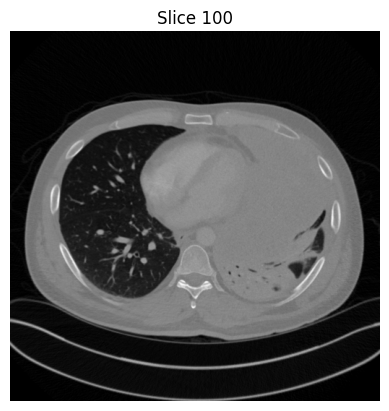

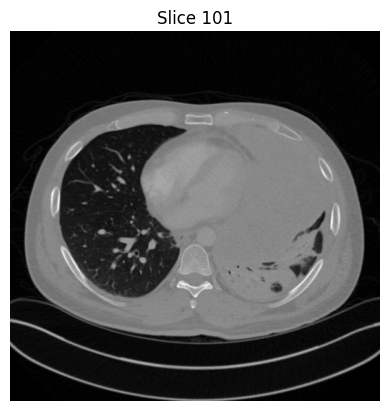

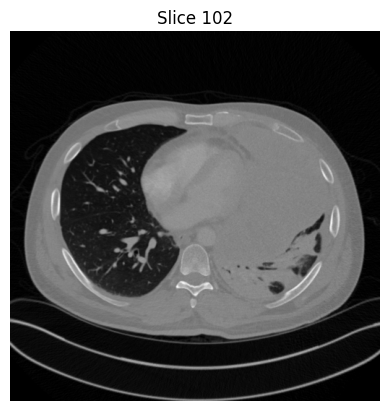

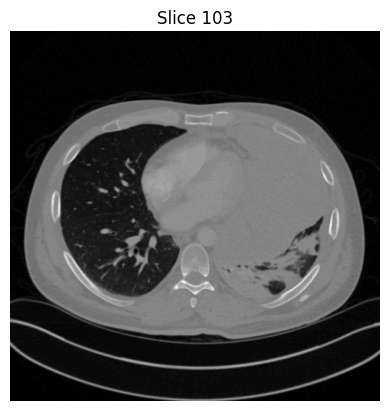

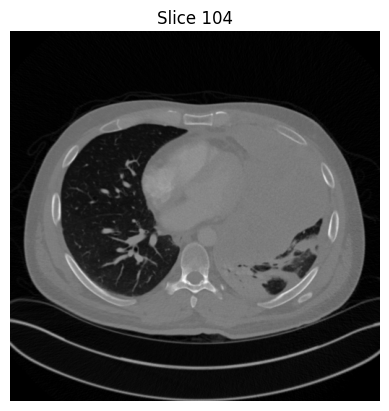

In [28]:
# visualize few consecutive slices
for i in range(100, 105):
    plt.imshow(ct_array[i], cmap='gray')
    plt.title(f"Slice {i}")
    plt.axis('off')
    plt.show()

In [ ]:
####TO undersatnd the same concept on DICOM data

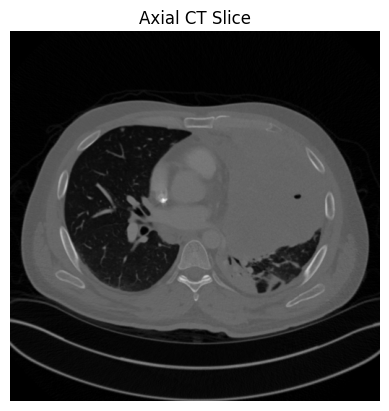

In [29]:
####Visualize DICOM slice
# show a middle slice
plt.imshow(ct_array[ct_array.shape[0]//2], cmap='gray')
plt.title("Axial CT Slice")
plt.axis('off')
plt.show()

In [30]:
# converting DICOM volume to NIFTI

sitk.WriteImage(image, "ct_from_dicom.nii")

print("DICOM converted to NIFTI")

DICOM converted to NIFTI


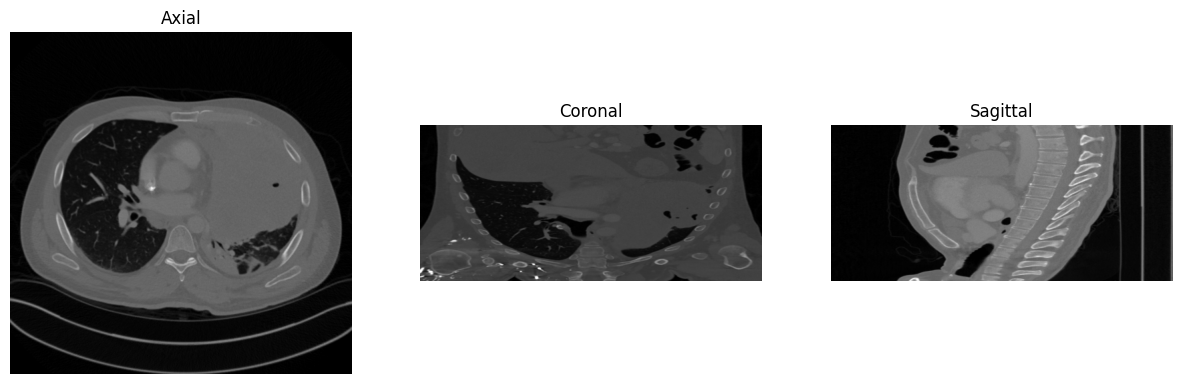

In [31]:
# showing axial, coronal, sagittal views

fig, axes = plt.subplots(1, 3, figsize=(15,5))

z = ct_array.shape[0] // 2
y = ct_array.shape[1] // 2
x = ct_array.shape[2] // 2

# axial
axes[0].imshow(ct_array[z], cmap='gray')
axes[0].set_title("Axial")

# coronal
axes[1].imshow(ct_array[:, y, :], cmap='gray')
axes[1].set_title("Coronal")

# sagittal
axes[2].imshow(ct_array[:, :, x], cmap='gray')
axes[2].set_title("Sagittal")

for ax in axes:
    ax.axis('off')

plt.show()

In [34]:
# converting back NIFTI to DICOM

nifti_image = sitk.ReadImage("ct_from_dicom.nii")

output_folder = "dicom_from_nifti"
os.makedirs(output_folder, exist_ok=True)

writer = sitk.ImageFileWriter()

for i in range(nifti_image.GetDepth()):
    slice_i = nifti_image[:, :, i]
    writer.SetFileName(os.path.join(output_folder, f"slice_{i}.dcm"))
    writer.Execute(slice_i)

print("NIFTI converted back to DICOM")

NIFTI converted back to DICOM
